# Runge Kunta 4 Solver for Stockes Particle 


## 1. Mathematics behind

According to notes [TODO : Add mathematics notes], we can describe the particle motion with this differential equation : 
$$ 
    \ddot{a} = 
    - \frac{1}{\tau_v} \dot{r}
    + \beta \cdot \left( g_{\mathcal{R}_2}(t) -  \Omega \times \left( \Omega \times r\right) + \dot{\Omega} \times r \right)
    -2 \gamma \left( \Omega \times \dot{v_{\mathcal{R}_2}} \right). 
$$

In [114]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import scipy

import src.core.conventions as conv 

kin = src.core.kinematics.CanonicalTwoAxis(n_axes=2)


## 2. Extract trajectory components and process physics vectors

In [115]:
# Read CSV trajectory and extract content 

# TRAJ_PATH = "../data/trajectories/traj1_inner_zero.csv"
# TRAJ_PATH = "../data/trajectories/traj2_biaxial_harmonic.csv"
TRAJ_PATH = "../data/trajectories/traj3_biaxial_desynchro.csv"
traj = pd.read_csv(TRAJ_PATH, comment="#")
print(traj)

np_traj = traj.to_numpy()
timestamp = (np_traj.T)[0]
theta1 = (np_traj.T)[1]
theta2 = (np_traj.T)[2]

       timestamp    theta1    theta2
0           0.00  0.349066  0.000000
1           0.01  0.349057  0.001218
2           0.02  0.349032  0.002437
3           0.03  0.348989  0.003655
4           0.04  0.348930  0.004874
...          ...       ...       ...
11995     119.95 -0.163876 -0.299208
11996     119.96 -0.166024 -0.299834
11997     119.97 -0.168164 -0.300456
11998     119.98 -0.170295 -0.301074
11999     119.99 -0.172418 -0.301689

[12000 rows x 3 columns]


In [116]:
# Process trajectory values

def get_gravity_positions(theta1, theta2): 
    """
    Process gravoity vector position using angles 
    and kinematics/conventions source files. 
    """
    g0 = conv.G_LAB
    angles = np.array([theta1, theta2]).T
    rot = kin.rotation(angles)
    return rot.apply(g0)

def get_omegas(theta1, theta2, timestamp): 
    """
    Process omega1 and omega1 corresponding 
    to angular velocities using variation rate formula. 
    - theta1 : inner axis orientation (rad)
    - theta2 : outer axis orientation (rad)
    - timestamp : corresponding time (s)
    """

    omega1 = np.gradient(theta1, timestamp)
    omega2 = np.gradient(theta2, timestamp)
    return omega1, omega2

def process_angular_velocity(theta1, omega1, omega2): 
    """
    Process angular velocity vector in R_2 referential frame 
    (the sample one) using this formula : 
    Omega = (
        - omega2 * sin(theta1)
        omega2 * cos(theta1)
        omega1    
    )
    - theta2 : outer axis orientation (rad)
    - omega1 : inner axis rotation speed (rad/s)
    - omega2 : outer axis rotation speed (rad/s)
    """

    Omegas = np.array([
        - omega2 * np.sin(theta1), 
        omega2 * np.cos(theta1), 
        omega1
    ])
    return Omegas 

g_pos = get_gravity_positions(theta1, theta2)
omega1, omega2 = get_omegas(theta1, theta2, timestamp)
Omega_r2 = process_angular_velocity(theta1, omega1, omega2)
Omega_r2_diff = np.gradient(Omega_r2, timestamp, axis=1)

## 3. Define the model and solve it using RK4

In [117]:
# Model definition 
rho_p = 1.202e3       # Particle density 
rho_f = 1.200e3       # Fluid density
radius = 0.15e-2     # Particle radium 
V_p = (4/3) * np.pi * radius**3
m_p = rho_p * V_p   # Particle mass 

mu = 1.412          # Glycerol dynnamic viscosity in kg/(m·s)
tau_v = (2/9) * (radius**2 * (rho_p + (1/2) * rho_f)) / mu 
beta = (rho_p - rho_f) / (rho_p + (1/2) * rho_f)
gamma = rho_p / (rho_p + (1/2) * rho_f)

# Initial conditions 
x_0 = np.array([0, 0, 5e-3])
v_0 = np.array([0, 0, 0])

# States 
N = len(timestamp)
states = np.zeros(shape=(N, 6))
states[0] = np.concat((x_0, v_0), axis=None)
dt = timestamp[1] - timestamp[0]


In [118]:
# Runge-Kunta 4 order processor 

def compute_acceleration(r, v, g_b, omega, omega_dot):
    """
    Process relatice acceleration a = dv/dt in the sample reference R_b. 
    - r : position vector at time t (,3)
    - v : speed vector at time t (,3)
    - omega : angular velocity at time t 
    - omega_dot : angular acceleration at time t
    """

    # Process viscosity Stokes' force
    f_drag = - (1.0 / tau_v) * v

    # Newton forces
    centrifugal = np.cross(omega, np.cross(omega, r))
    euler = np.cross(omega_dot, r)
    f_vol = beta * (g_b - centrifugal - euler)

    # Coriolis force
    f_coriolis = - 2.0 * gamma * np.cross(omega, v)

    return f_drag + f_vol + f_coriolis


def rhs(state, g_b, omega, omega_dot):
    """
    Process the second member of the 2 order EDO : dX/dt = [v, a].
    - state : concat of position and velocity (,6)
    - g_b : gravity vector orientation (,3)
    - omega : angular velocity at time t 
    - omega_dot : angular acceleration at time t
    """
    r = state[0:3]
    v = state[3:6]
    a = compute_acceleration(r, v, g_b, omega, omega_dot)
    return np.concatenate([v, a])

In [ ]:

# Temporal integration 
for n in range(N - 1):
    # Kinematics calculus at t
    g_n = g_pos[n]
    omega_n = Omega_r2[:, n]
    omega_dot_n = Omega_r2_diff[:, n]

    # Kinematic calculus at t_{n+1}
    g_next = g_pos[n + 1]
    omega_next = Omega_r2[:, n + 1]
    omega_dot_next = Omega_r2_diff[:, n + 1]

    # Linear demi-step approximation at t_{n + 1/2}
    g_mid = 0.5 * (g_n + g_next)
    omega_mid = 0.5 * (omega_n + omega_next)
    omega_dot_mid = 0.5 * (omega_dot_n + omega_dot_next)

    # Current state
    x_n = states[n]

    # 4 RK4 coefficients
    k1 = rhs(x_n, g_n, omega_n, omega_dot_n)
    k2 = rhs(x_n + 0.5 * dt * k1, g_mid, omega_mid, omega_dot_mid)
    k3 = rhs(x_n + 0.5 * dt * k2, g_mid, omega_mid, omega_dot_mid)
    k4 = rhs(x_n + dt * k3, g_next, omega_next, omega_dot_next)

    # Update X_{n+1} state
    states[n + 1] = x_n + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

from scipy.interpolate import interp1d

# Interpolation temporelle continue le long de l'axe temporel (axis=0 pour g_pos, axis=1 pour les Omegas)
interp_g = interp1d(timestamp, g_pos, axis=0, fill_value="extrapolate")
interp_omega = interp1d(timestamp, Omega_r2, axis=1, fill_value="extrapolate")
interp_omega_dot = interp1d(timestamp, Omega_r2_diff, axis=1, fill_value="extrapolate")

def rhs_scipy(t, y):
    """
    Second membre au format solve_ivp : dy/dt = f(t, y).
    y = [x, y, z, vx, vy, vz]
    """
    r = y[0:3]
    v = y[3:6]

    # Évaluation continue des grandeurs cinématiques à l'instant t
    g_b = interp_g(t)
    omega = interp_omega(t)
    omega_dot = interp_omega_dot(t)

    # Forces
    f_drag = - (1.0 / tau_v) * v
    centrifugal = np.cross(omega, np.cross(omega, r))
    euler = np.cross(omega_dot, r)
    f_vol = beta * (g_b - centrifugal - euler)
    f_coriolis = - 2.0 * gamma * np.cross(omega, v)

    # dy/dt = [v, a]
    a = f_drag + f_vol + f_coriolis
    return np.concatenate([v, a])

from scipy.integrate import solve_ivp

# État initial X_0 (taille 6)
y0 = np.concatenate([x_0, v_0])

# Intégration raide inconditionnellement stable
sol = solve_ivp(
    fun=rhs_scipy,
    t_span=(timestamp[0], timestamp[-1]),
    y0=y0,
    method="Radau",       # Essentiel face à tau_v petit
    t_eval=timestamp,     # Points de sortie souhaités
    rtol=1e-6,
    atol=1e-8
)

print("Success :", sol.success)
print("Status  :", sol.status)
print("Message :", sol.message)
print("Nfev    :", sol.nfev)  # Nombre d'évaluations de rhs
print(g_pos.shape, Omega_r2.shape, Omega_r2_diff.shape)

# Extract final positions and speeds
r_t = states[:, 0:3]  # (N, 3) in meters
v_t = states[:, 3:6]  # (N, 3) in m/s

In [123]:
def v_limit(r, g_b, omega, omega_dot):
    centrifugal = np.cross(omega, np.cross(omega, r))
    euler = np.cross(omega_dot, r)
    return tau_v * beta * (g_b - centrifugal - euler)

r_t = np.zeros((N, 3))
r_t[0] = x_0

for n in range(N - 1):
    g_n, g_next = g_pos[n], g_pos[n + 1]
    w_n, w_next = Omega_r2[:, n], Omega_r2[:, n + 1]
    dw_n, dw_next = Omega_r2_diff[:, n], Omega_r2_diff[:, n + 1]

    g_mid = 0.5 * (g_n + g_next)
    w_mid = 0.5 * (w_n + w_next)
    dw_mid = 0.5 * (dw_n + dw_next)

    rn = r_t[n]
    k1 = v_limit(rn, g_n, w_n, dw_n)
    k2 = v_limit(rn + 0.5 * dt * k1, g_mid, w_mid, dw_mid)
    k3 = v_limit(rn + 0.5 * dt * k2, g_mid, w_mid, dw_mid)
    k4 = v_limit(rn + dt * k3, g_next, w_next, dw_next)

    r_t[n + 1] = rn + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    

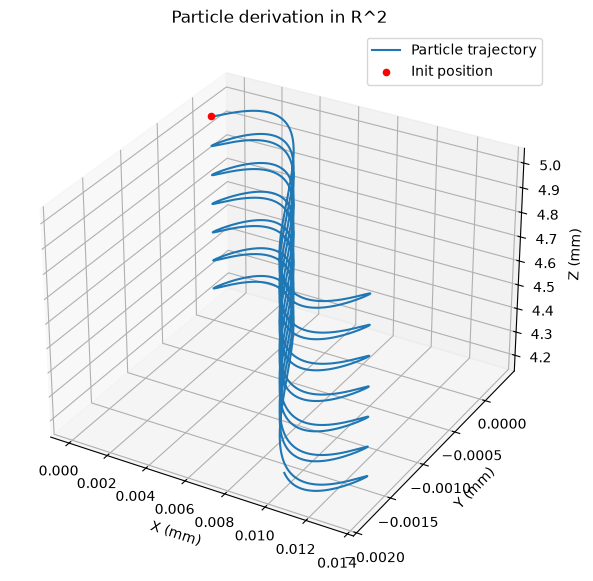

Re_p max : 0.0000e+00


In [124]:
# Plot trajectory 
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection="3d")
ax.plot(r_t[:, 0] * 1e3, r_t[:, 1] * 1e3, r_t[:, 2] * 1e3, label="Particle trajectory")
ax.scatter(r_t[0, 0] * 1e3, r_t[0, 1] * 1e3, r_t[0, 2] * 1e3, color="red", label="Init position")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.set_title("Particle derivation in R^2")
ax.legend()
plt.show()

v_norm = np.linalg.norm(v_t, axis=1)
re_p = (2.0 * radius * rho_f * v_norm) / mu
print(f"Re_p max : {np.max(re_p):.4e}")